In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import warnings

warnings.simplefilter(action='ignore', category=Warning)

fsize = 10
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

# LLM Extraction Evaluation

Compares LLM extraction (`evidence_llm/extracted_txt.json`) against human curation (`evidence_human/extracted.json`) at multiple levels:

1. **Source verification**: fraction of LLM extractions with verified source rationale, group label, and feature label
2. **Feature-level**: unique gene overlap (ignoring cell type assignment)
3. **Pair-level**: (group_name, feature) overlap — correct gene assigned to correct cell type
4. **Per-cell-type gene F1**: mean F1 across shared cell types
5. **Per-cell-type stacked bar chart**: LLM-only / intersection / human-only genes per cell type

# Helpers

In [2]:
def set_itx(a, b, vals=False):
    itx = np.intersect1d(a, b)
    if vals:
        return itx
    return itx.shape[0]


def set_diff(a, b, vals=False):
    diff = np.setdiff1d(a, b)
    if vals:
        return diff
    return diff.shape[0]


def set_cmp(a, b, vals=False):
    return (set_diff(a, b, vals), set_itx(a, b, vals), set_diff(b, a, vals))


def build_groups(df, feature_col="feature_id"):
    """Build dict of group_name -> set of feature values."""
    groups = {}
    for _, r in df.iterrows():
        gn = r.get("group_name")
        fn = r.get(feature_col)
        if pd.notna(gn) and pd.notna(fn) and gn and fn:
            groups.setdefault(gn, set()).add(fn)
    return groups


def build_pairs(df, feature_col="feature_id"):
    """Build set of (group_name, feature) pairs."""
    pairs = set()
    for _, r in df.iterrows():
        gn = r.get("group_name")
        fn = r.get(feature_col)
        if pd.notna(gn) and pd.notna(fn) and gn and fn:
            pairs.add((gn, fn))
    return pairs


def compare_ct_features(df1, df2, celltypes, label1, label2, feature_col="feature_id"):
    """Per-cell-type feature comparison. Returns (matrix, missing_in_df1, missing_in_df2)."""
    t1 = df1.groupby("group_name")[feature_col].apply(list).reindex(celltypes, fill_value=[])
    t2 = df2.groupby("group_name")[feature_col].apply(list).reindex(celltypes, fill_value=[])

    l = t1.combine(t2, lambda a, b: np.setdiff1d(a, b).shape[0]).rename(label1)
    x = t1.combine(t2, lambda a, b: np.intersect1d(a, b).shape[0]).rename("x")
    r = t1.combine(t2, lambda a, b: np.setdiff1d(b, a).shape[0]).rename(label2)
    mtx = pd.concat([l, x, r], axis=1)
    nt1 = np.where(t1.apply(lambda x: len(x)) == 0)[0]
    nt2 = np.where(t2.apply(lambda x: len(x)) == 0)[0]
    return (mtx.values, nt1, nt2)

# Load data

In [3]:
datasets = [
    "adipose_Emont2022",
    "adipose_Hildreth2021",
    "bone_He2021",
    "eye_Gautam2021",
    "lung_Adams2020",
    "ovary_Wagner2020",
    "testis_Shamis2020",
]

labels = {
    "adipose_Emont2022": "Adipose (Emont)",
    "adipose_Hildreth2021": "Adipose (Hildreth)",
    "bone_He2021": "Bone (He)",
    "eye_Gautam2021": "Eye (Gautam)",
    "lung_Adams2020": "Lung (Adams)",
    "ovary_Wagner2020": "Ovary (Wagner)",
    "testis_Shamis2020": "Testis (Shamis)",
}

data = []

for ds in datasets:
    fn_hmn = f"../data/{ds}/evidence_human/extracted.json"
    fn_llm = f"../data/{ds}/evidence_llm/extracted_txt.json"

    hmn = pd.read_json(fn_hmn).dropna(subset=["feature_id"])
    llm = pd.read_json(fn_llm).dropna(subset=["feature_id"])

    # split human into text and image
    txt = hmn.query("source_type == 'text'")
    img = hmn.query("source_type == 'image'")

    celltypes = np.union1d(
        hmn["group_name"].dropna().unique(),
        llm["group_name"].dropna().unique()
    )

    data.append({
        "ds": ds,
        "label": labels[ds],
        "hmn": hmn,
        "txt": txt,
        "img": img,
        "llm": llm,
        "celltypes": celltypes,
    })

    print(f"{labels[ds]:>22s}: hmn={len(hmn):>4d} (txt={len(txt):>3d}, img={len(img):>3d}), "
          f"llm={len(llm):>3d}, celltypes={len(celltypes)}")

       Adipose (Emont): hmn= 387 (txt= 31, img=356), llm= 40, celltypes=50
    Adipose (Hildreth): hmn= 300 (txt= 73, img=227), llm= 58, celltypes=31
             Bone (He): hmn= 816 (txt=497, img=319), llm= 48, celltypes=27
          Eye (Gautam): hmn= 514 (txt= 31, img=483), llm= 51, celltypes=33
          Lung (Adams): hmn= 147 (txt= 36, img=111), llm= 53, celltypes=21
        Ovary (Wagner): hmn= 138 (txt= 58, img= 80), llm= 35, celltypes=8
       Testis (Shamis): hmn= 195 (txt=128, img= 67), llm= 95, celltypes=19


# 1. Source verification

LLM extractions include a `_verification` field from `mrkr verify`. We check:
- `source_rationale_found`: was the source rationale found verbatim in the manuscript?
- `group_label_found`: was the group label aligned within the source rationale?
- `feature_label_found`: was the feature label aligned within the source rationale?
- `all_verified`: all three checks passed

In [4]:
verif_rows = []

for d in data:
    llm = d["llm"]
    if "_verification" not in llm.columns:
        continue

    v = llm["_verification"].apply(pd.Series)
    n = len(v)

    verif_rows.append({
        "dataset": d["label"],
        "n_extractions": n,
        "source_rationale": v["source_rationale_found"].sum(),
        "source_rationale_pct": 100 * v["source_rationale_found"].mean(),
        "group_label": v["group_label_found"].sum(),
        "group_label_pct": 100 * v["group_label_found"].mean(),
        "feature_label": v["feature_label_found"].sum(),
        "feature_label_pct": 100 * v["feature_label_found"].mean(),
        "all_verified": v["all_verified"].sum(),
        "all_verified_pct": 100 * v["all_verified"].mean(),
    })

verif_df = pd.DataFrame(verif_rows)
verif_df[["dataset", "n_extractions",
          "source_rationale", "source_rationale_pct",
          "group_label", "group_label_pct",
          "feature_label", "feature_label_pct",
          "all_verified", "all_verified_pct"]]

,dataset,n_extractions,source_rationale,source_rationale_pct,group_label,group_label_pct,feature_label,feature_label_pct,all_verified,all_verified_pct
0,Adipose (Emont),40,40,100.0,40,100.000000,40,100.000000,40,100.000000
1,Adipose (Hildreth),58,58,100.0,56,96.551724,58,100.000000,56,96.551724
2,Bone (He),48,48,100.0,47,97.916667,47,97.916667,46,95.833333
3,Eye (Gautam),51,51,100.0,46,90.196078,51,100.000000,46,90.196078
4,Lung (Adams),53,53,100.0,45,84.905660,53,100.000000,45,84.905660
5,Ovary (Wagner),35,35,100.0,34,97.142857,35,100.000000,34,97.142857
6,Testis (Shamis),95,95,100.0,86,90.526316,90,94.736842,86,90.526316


In [5]:
# Summary
total_ext = verif_df["n_extractions"].sum()
total_sr = verif_df["source_rationale"].sum()
total_gl = verif_df["group_label"].sum()
total_fl = verif_df["feature_label"].sum()
total_av = verif_df["all_verified"].sum()

print(f"Total LLM extractions: {total_ext}")
print(f"Source rationale found: {total_sr}/{total_ext} ({100*total_sr/total_ext:.1f}%)")
print(f"Group label found:     {total_gl}/{total_ext} ({100*total_gl/total_ext:.1f}%)")
print(f"Feature label found:   {total_fl}/{total_ext} ({100*total_fl/total_ext:.1f}%)")
print(f"All verified:          {total_av}/{total_ext} ({100*total_av/total_ext:.1f}%)")

Total LLM extractions: 380
Source rationale found: 380/380 (100.0%)
Group label found:     354/380 (93.2%)
Feature label found:   374/380 (98.4%)
All verified:          353/380 (92.9%)


# 2. Feature-level comparison (unique genes)

How many unique genes does LLM extraction recover compared to human curation?
We compare using `feature_id` (Ensembl IDs) to avoid gene name ambiguity.

In [6]:
feat_rows = []

for d in data:
    h_fids = set(d["hmn"]["feature_id"].dropna())
    h_txt_fids = set(d["txt"]["feature_id"].dropna())
    h_img_fids = set(d["img"]["feature_id"].dropna())
    l_fids = set(d["llm"]["feature_id"].dropna())

    shared_all = h_fids & l_fids
    shared_txt = h_txt_fids & l_fids

    feat_rows.append({
        "dataset": d["label"],
        "hmn_all": len(h_fids),
        "hmn_txt": len(h_txt_fids),
        "hmn_img": len(h_img_fids),
        "llm": len(l_fids),
        "shared_all": len(shared_all),
        "shared_txt": len(shared_txt),
        "jaccard_all": len(shared_all) / len(h_fids | l_fids) if (h_fids | l_fids) else 0,
        "jaccard_txt": len(shared_txt) / len(h_txt_fids | l_fids) if (h_txt_fids | l_fids) else 0,
        "recall_all": len(shared_all) / len(h_fids) if h_fids else 0,
        "recall_txt": len(shared_txt) / len(h_txt_fids) if h_txt_fids else 0,
        "precision": len(shared_all) / len(l_fids) if l_fids else 0,
    })

feat_df = pd.DataFrame(feat_rows)
feat_df

,dataset,hmn_all,hmn_txt,hmn_img,llm,shared_all,shared_txt,jaccard_all,jaccard_txt,recall_all,recall_txt,precision
0,Adipose (Emont),105,23,104,33,25,22,0.221239,0.647059,0.238095,0.956522,0.757576
1,Adipose (Hildreth),141,53,124,51,46,42,0.315068,0.677419,0.326241,0.792453,0.901961
2,Bone (He),75,69,29,34,29,28,0.362500,0.373333,0.386667,0.405797,0.852941
3,Eye (Gautam),94,22,82,44,24,20,0.210526,0.434783,0.255319,0.909091,0.545455
4,Lung (Adams),124,33,99,49,35,33,0.253623,0.673469,0.282258,1.000000,0.714286
5,Ovary (Wagner),62,46,54,30,27,27,0.415385,0.551020,0.435484,0.586957,0.900000
6,Testis (Shamis),125,91,59,74,70,68,0.542636,0.701031,0.560000,0.747253,0.945946


In [7]:
# Feature-level summary
print(f"{'Dataset':>22s}  {'hmn':>4s} {'llm':>4s} {'shared':>6s} {'recall':>7s} {'precision':>9s} {'jaccard':>7s}")
print("-" * 70)
for _, r in feat_df.iterrows():
    print(f"{r['dataset']:>22s}  {r['hmn_all']:>4.0f} {r['llm']:>4.0f} {r['shared_all']:>6.0f} "
          f"{r['recall_all']:>7.0%} {r['precision']:>9.0%} {r['jaccard_all']:>7.2f}")
print("-" * 70)
print(f"{'Mean':>22s}  {feat_df['hmn_all'].mean():>4.0f} {feat_df['llm'].mean():>4.0f} "
      f"{feat_df['shared_all'].mean():>6.0f} {feat_df['recall_all'].mean():>7.0%} "
      f"{feat_df['precision'].mean():>9.0%} {feat_df['jaccard_all'].mean():>7.2f}")

               Dataset   hmn  llm shared  recall precision jaccard
----------------------------------------------------------------------
       Adipose (Emont)   105   33     25     24%       76%    0.22
    Adipose (Hildreth)   141   51     46     33%       90%    0.32
             Bone (He)    75   34     29     39%       85%    0.36
          Eye (Gautam)    94   44     24     26%       55%    0.21
          Lung (Adams)   124   49     35     28%       71%    0.25
        Ovary (Wagner)    62   30     27     44%       90%    0.42
       Testis (Shamis)   125   74     70     56%       95%    0.54
----------------------------------------------------------------------
                  Mean   104   45     37     35%       80%    0.33


# 3. Pair-level comparison (group_name + feature_id)

Are genes assigned to the correct cell type?

In [8]:
pair_rows = []

for d in data:
    # LLM vs human-all
    l_pairs = build_pairs(d["llm"])
    h_pairs = build_pairs(d["hmn"])
    h_txt_pairs = build_pairs(d["txt"])

    tp_all = len(l_pairs & h_pairs)
    tp_txt = len(l_pairs & h_txt_pairs)

    p_all = tp_all / len(l_pairs) if l_pairs else 0
    r_all = tp_all / len(h_pairs) if h_pairs else 0
    f_all = 2 * p_all * r_all / (p_all + r_all) if (p_all + r_all) > 0 else 0

    p_txt = tp_txt / len(l_pairs) if l_pairs else 0
    r_txt = tp_txt / len(h_txt_pairs) if h_txt_pairs else 0
    f_txt = 2 * p_txt * r_txt / (p_txt + r_txt) if (p_txt + r_txt) > 0 else 0

    pair_rows.append({
        "dataset": d["label"],
        "llm_pairs": len(l_pairs),
        "hmn_pairs": len(h_pairs),
        "hmn_txt_pairs": len(h_txt_pairs),
        "shared_all": tp_all,
        "shared_txt": tp_txt,
        "precision_all": p_all,
        "recall_all": r_all,
        "f1_all": f_all,
        "precision_txt": p_txt,
        "recall_txt": r_txt,
        "f1_txt": f_txt,
    })

pair_df = pd.DataFrame(pair_rows)
pair_df[["dataset", "llm_pairs", "hmn_pairs", "hmn_txt_pairs",
         "shared_all", "precision_all", "recall_all", "f1_all",
         "shared_txt", "precision_txt", "recall_txt", "f1_txt"]]

,dataset,llm_pairs,hmn_pairs,hmn_txt_pairs,shared_all,precision_all,recall_all,f1_all,shared_txt,precision_txt,recall_txt,f1_txt
0,Adipose (Emont),34,346,30,21,0.617647,0.060694,0.110526,20,0.588235,0.666667,0.625000
1,Adipose (Hildreth),58,234,66,49,0.844828,0.209402,0.335616,48,0.827586,0.727273,0.774194
2,Bone (He),41,370,98,32,0.780488,0.086486,0.155718,31,0.756098,0.316327,0.446043
3,Eye (Gautam),48,251,24,26,0.541667,0.103586,0.173913,21,0.437500,0.875000,0.583333
4,Lung (Adams),49,135,33,34,0.693878,0.251852,0.369565,33,0.673469,1.000000,0.804878
5,Ovary (Wagner),35,58,37,28,0.800000,0.482759,0.602151,28,0.800000,0.756757,0.777778
6,Testis (Shamis),85,171,123,74,0.870588,0.432749,0.578125,73,0.858824,0.593496,0.701923


In [9]:
# Pair-level summary
print("Pair-level (vs human-all):")
print(f"  Mean precision: {pair_df['precision_all'].mean():.2f}")
print(f"  Mean recall:    {pair_df['recall_all'].mean():.2f}")
print(f"  Mean F1:        {pair_df['f1_all'].mean():.2f}")
print()
print("Pair-level (vs human-text only):")
print(f"  Mean precision: {pair_df['precision_txt'].mean():.2f}")
print(f"  Mean recall:    {pair_df['recall_txt'].mean():.2f}")
print(f"  Mean F1:        {pair_df['f1_txt'].mean():.2f}")

Pair-level (vs human-all):
  Mean precision: 0.74
  Mean recall:    0.23
  Mean F1:        0.33

Pair-level (vs human-text only):
  Mean precision: 0.71
  Mean recall:    0.71
  Mean F1:        0.67


# 4. Per-cell-type gene F1

For each cell type shared between LLM and human, compute gene-level F1 on feature_id.

In [10]:
ct_f1_rows = []

for d in data:
    llm_g = build_groups(d["llm"])
    hmn_g = build_groups(d["hmn"])
    txt_g = build_groups(d["txt"])

    all_cts = sorted(set(llm_g) | set(hmn_g))
    for ct in all_cts:
        e = llm_g.get(ct, set())
        h = hmn_g.get(ct, set())
        t = txt_g.get(ct, set())

        def _f1(a, b):
            tp = len(a & b)
            p = tp / len(a) if a else 0
            r = tp / len(b) if b else 0
            return 2 * p * r / (p + r) if (p + r) > 0 else 0

        ct_f1_rows.append({
            "dataset": d["label"],
            "cell_type": ct,
            "n_hmn": len(h),
            "n_txt": len(t),
            "n_llm": len(e),
            "f1_all": _f1(e, h) if h and e else np.nan,
            "f1_txt": _f1(e, t) if t and e else np.nan,
        })

ct_f1_df = pd.DataFrame(ct_f1_rows)

# Mean per-cell-type F1 by dataset
mean_f1 = ct_f1_df.groupby("dataset").agg(
    mean_f1_all=("f1_all", "mean"),
    mean_f1_txt=("f1_txt", "mean"),
    n_shared_all=("f1_all", "count"),
    n_shared_txt=("f1_txt", "count"),
).reindex([labels[ds] for ds in datasets])

mean_f1

,mean_f1_all,mean_f1_txt,n_shared_all,n_shared_txt
dataset,,,,
Adipose (Emont),0.368878,0.819780,15,13
Adipose (Hildreth),0.518879,0.845975,17,16
Bone (He),0.436606,0.647619,11,11
Eye (Gautam),0.324807,0.822222,17,11
Lung (Adams),0.582849,0.924181,6,6
Ovary (Wagner),0.590329,0.804365,7,7
Testis (Shamis),0.661999,0.788971,14,13


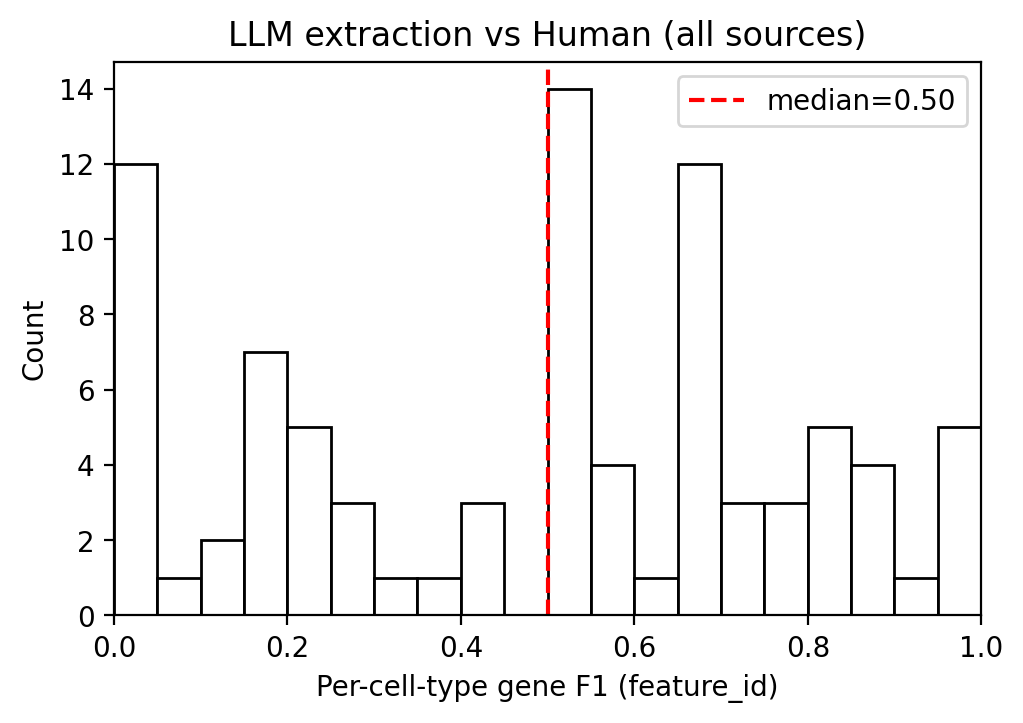

In [11]:
# Distribution of per-cell-type F1 (vs all human)
fig, ax = plt.subplots(figsize=(5, 3.5), constrained_layout=True)

vals = ct_f1_df["f1_all"].dropna()
ax.hist(vals, bins=20, edgecolor="k", facecolor="white")
ax.axvline(vals.median(), color="red", linestyle="--",
           label=f"median={vals.median():.2f}")
ax.set(**{
    "xlabel": "Per-cell-type gene F1 (feature_id)",
    "ylabel": "Count",
    "title": "LLM extraction vs Human (all sources)",
    "xlim": (0, 1),
})
ax.legend()
plt.show()

In [12]:
print(f"Overall mean per-cell-type gene F1 (vs all human):  {ct_f1_df['f1_all'].mean():.2f}")
print(f"Overall mean per-cell-type gene F1 (vs text human): {ct_f1_df['f1_txt'].mean():.2f}")

Overall mean per-cell-type gene F1 (vs all human):  0.48
Overall mean per-cell-type gene F1 (vs text human): 0.80


# 5. Per-cell-type stacked bar chart (human text vs LLM)

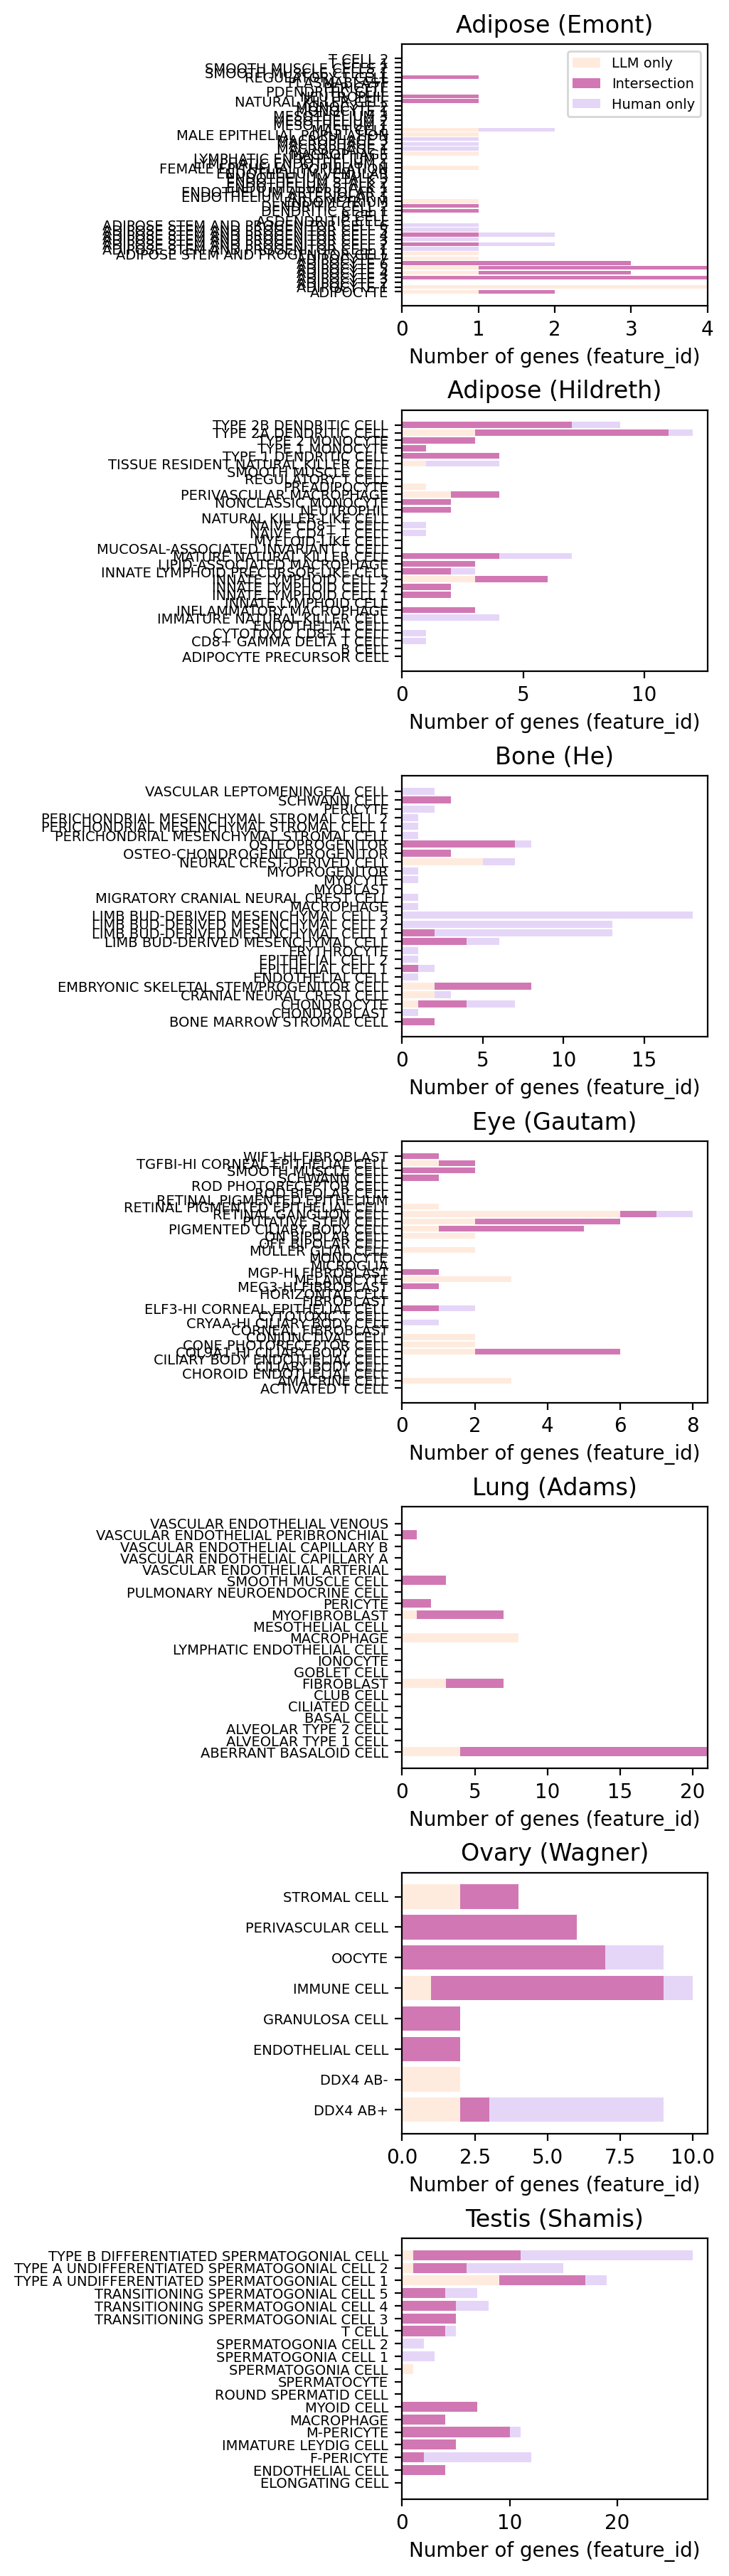

In [13]:
lc = "#FFB07C"
ic = "#D178B4"
rc = "#9B5DE5"

fig, axs = plt.subplots(figsize=(5, 18), nrows=len(data), constrained_layout=True)

for ax, d in zip(axs, data):
    celltypes = d["celltypes"]

    mtx, nt1, nt2 = compare_ct_features(d["txt"], d["llm"], celltypes, "hmn_txt", "llm")

    # order: LLM-only | intersection | human-only
    y1 = mtx[:, 2]  # llm only (right diff)
    y2 = mtx[:, 1]  # intersection
    y3 = mtx[:, 0]  # human only (left diff)

    x = np.arange(len(celltypes))

    ax.barh(x, y1, color=lc, alpha=0.25, label="LLM only")
    ax.barh(x, y2, left=y1, color=ic, alpha=1.0, label="Intersection")
    ax.barh(x, y3, left=y1 + y2, color=rc, alpha=0.25, label="Human only")

    ax.set(**{
        "yticks": x,
        "yticklabels": celltypes,
        "xlabel": "Number of genes (feature_id)",
        "title": d["label"],
    })
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
    if ax == axs[0]:
        ax.legend(fontsize=7)

plt.show()

# 6. Data-level comparison (data_id + group_name + feature_id)

The most stringent level: is the gene assigned to the correct cell type AND linked to the correct DEG source?

In [14]:
def build_triples(df):
    """Build set of (data_id, group_name, feature_id) triples."""
    triples = set()
    for _, r in df.iterrows():
        did = r.get("data_id")
        gn = r.get("group_name")
        fn = r.get("feature_id")
        if pd.notna(did) and pd.notna(gn) and pd.notna(fn) and did and gn and fn:
            triples.add((did, gn, fn))
    return triples


data_rows = []

for d in data:
    l_triples = build_triples(d["llm"])
    h_triples = build_triples(d["hmn"])
    h_txt_triples = build_triples(d["txt"])

    tp_all = len(l_triples & h_triples)
    tp_txt = len(l_triples & h_txt_triples)

    p_all = tp_all / len(l_triples) if l_triples else 0
    r_all = tp_all / len(h_triples) if h_triples else 0
    f_all = 2 * p_all * r_all / (p_all + r_all) if (p_all + r_all) > 0 else 0

    p_txt = tp_txt / len(l_triples) if l_triples else 0
    r_txt = tp_txt / len(h_txt_triples) if h_txt_triples else 0
    f_txt = 2 * p_txt * r_txt / (p_txt + r_txt) if (p_txt + r_txt) > 0 else 0

    data_rows.append({
        "dataset": d["label"],
        "llm_triples": len(l_triples),
        "hmn_triples": len(h_triples),
        "hmn_txt_triples": len(h_txt_triples),
        "shared_all": tp_all,
        "shared_txt": tp_txt,
        "precision_all": p_all,
        "recall_all": r_all,
        "f1_all": f_all,
        "precision_txt": p_txt,
        "recall_txt": r_txt,
        "f1_txt": f_txt,
    })

data_df = pd.DataFrame(data_rows)
data_df[["dataset", "llm_triples", "hmn_triples", "hmn_txt_triples",
         "shared_all", "precision_all", "recall_all", "f1_all"]]

,dataset,llm_triples,hmn_triples,hmn_txt_triples,shared_all,precision_all,recall_all,f1_all
0,Adipose (Emont),28,346,30,18,0.642857,0.052023,0.096257
1,Adipose (Hildreth),58,245,66,48,0.827586,0.195918,0.316832
2,Bone (He),43,385,102,34,0.790698,0.088312,0.158879
3,Eye (Gautam),47,461,28,26,0.553191,0.056399,0.102362
4,Lung (Adams),49,139,33,23,0.469388,0.165468,0.244681
5,Ovary (Wagner),35,67,37,27,0.771429,0.402985,0.529412
6,Testis (Shamis),94,187,123,74,0.787234,0.395722,0.526690


In [15]:
# Data-level summary
print("Data-level (vs human-all):")
print(f"  Mean precision: {data_df['precision_all'].mean():.2f}")
print(f"  Mean recall:    {data_df['recall_all'].mean():.2f}")
print(f"  Mean F1:        {data_df['f1_all'].mean():.2f}")
print()
print("Data-level (vs human-text):")
print(f"  Mean precision: {data_df['precision_txt'].mean():.2f}")
print(f"  Mean recall:    {data_df['recall_txt'].mean():.2f}")
print(f"  Mean F1:        {data_df['f1_txt'].mean():.2f}")

Data-level (vs human-all):
  Mean precision: 0.69
  Mean recall:    0.19
  Mean F1:        0.28

Data-level (vs human-text):
  Mean precision: 0.65
  Mean recall:    0.60
  Mean F1:        0.60


# 7. Precision-recall scatter (pair-level and data-level)

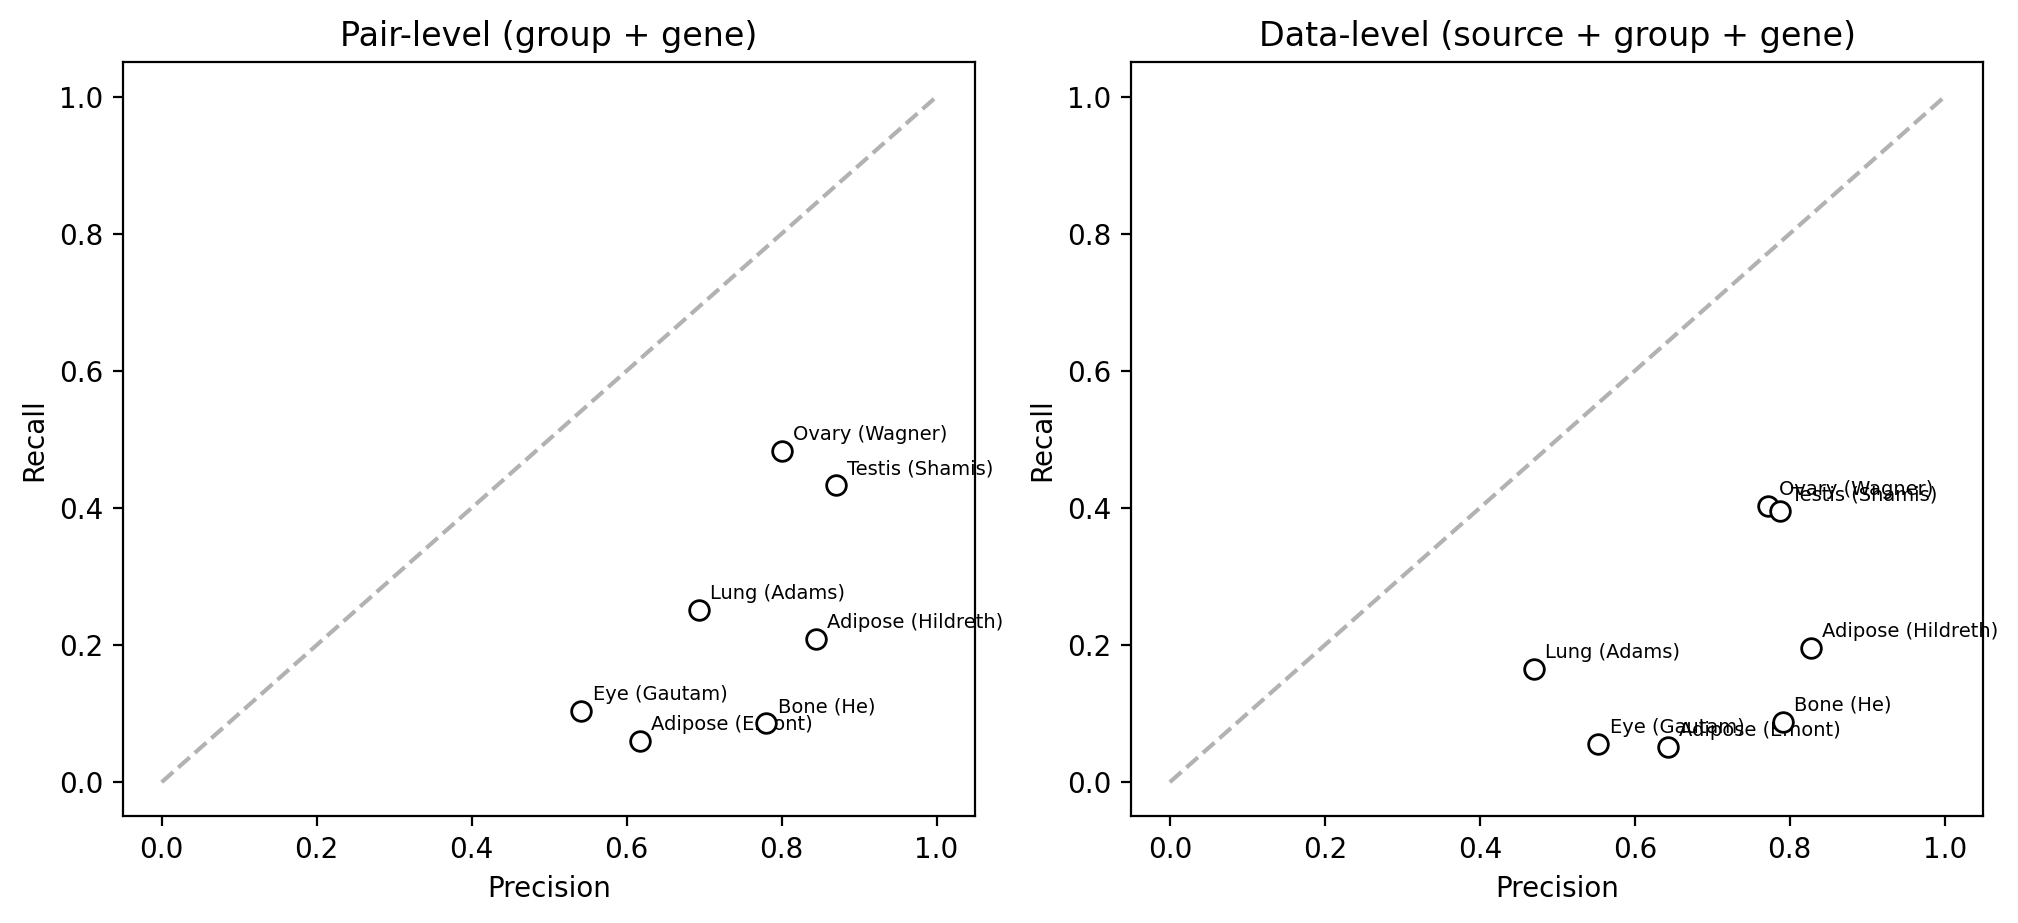

In [16]:
fig, axs = plt.subplots(figsize=(10, 4.5), ncols=2, constrained_layout=True)

for ax, df, title in zip(axs,
    [pair_df, data_df],
    ["Pair-level (group + gene)", "Data-level (source + group + gene)"]
):
    ax.scatter(df["precision_all"], df["recall_all"],
              edgecolors="k", facecolor="white", s=50, zorder=5)

    for _, r in df.iterrows():
        ax.annotate(r["dataset"], (r["precision_all"], r["recall_all"]),
                    xytext=(4, 4), textcoords="offset points", fontsize=7)

    ax.set(**{
        "xlabel": "Precision",
        "ylabel": "Recall",
        "xlim": (-0.05, 1.05),
        "ylim": (-0.05, 1.05),
        "title": title,
    })
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)

plt.show()

# 9. Summary table for tex

In [19]:
# Combine all metrics into one summary table
summary_rows = []

for i, d in enumerate(data):
    lbl = d["label"]

    # verification
    vr = verif_df[verif_df["dataset"] == lbl].iloc[0]

    # feature-level
    fr = feat_df[feat_df["dataset"] == lbl].iloc[0]

    # pair-level
    pr = pair_df[pair_df["dataset"] == lbl].iloc[0]

    # data-level
    dr = data_df[data_df["dataset"] == lbl].iloc[0]

    # per-cell-type F1
    mf = mean_f1.loc[lbl]

    summary_rows.append({
        "dataset": lbl,
        "n_llm": int(vr["n_extractions"]),
        "n_hmn": len(d["hmn"]),
        "verification_pct": vr["all_verified_pct"],
        "feat_jaccard": fr["jaccard_all"],
        "pair_f1": pr["f1_all"],
        "pair_precision": pr["precision_all"],
        "pair_recall": pr["recall_all"],
        "data_f1": dr["f1_all"],
        "ct_gene_f1": mf["mean_f1_all"],
    })

summary = pd.DataFrame(summary_rows)
summary

,dataset,n_llm,n_hmn,verification_pct,feat_jaccard,pair_f1,pair_precision,pair_recall,data_f1,ct_gene_f1
0,Adipose (Emont),40,387,100.000000,0.221239,0.110526,0.617647,0.060694,0.096257,0.368878
1,Adipose (Hildreth),58,300,96.551724,0.315068,0.335616,0.844828,0.209402,0.316832,0.518879
2,Bone (He),48,816,95.833333,0.362500,0.155718,0.780488,0.086486,0.158879,0.436606
3,Eye (Gautam),51,514,90.196078,0.210526,0.173913,0.541667,0.103586,0.102362,0.324807
4,Lung (Adams),53,147,84.905660,0.253623,0.369565,0.693878,0.251852,0.244681,0.582849
5,Ovary (Wagner),35,138,97.142857,0.415385,0.602151,0.800000,0.482759,0.529412,0.590329
6,Testis (Shamis),95,195,90.526316,0.542636,0.578125,0.870588,0.432749,0.526690,0.661999


In [20]:
# Print summary for tex
print(f"{'Dataset':>22s} {'LLM':>4s} {'Hmn':>4s} {'Verif%':>6s} {'FeatJ':>6s} "
      f"{'PairP':>6s} {'PairR':>6s} {'PairF1':>6s} {'DataF1':>6s} {'CtF1':>6s}")
print("-" * 85)
for _, r in summary.iterrows():
    print(f"{r['dataset']:>22s} {r['n_llm']:>4.0f} {r['n_hmn']:>4.0f} "
          f"{r['verification_pct']:>5.1f}% {r['feat_jaccard']:>6.2f} "
          f"{r['pair_precision']:>6.2f} {r['pair_recall']:>6.2f} "
          f"{r['pair_f1']:>6.2f} {r['data_f1']:>6.2f} {r['ct_gene_f1']:>6.2f}")
print("-" * 85)
print(f"{'Mean':>22s} {summary['n_llm'].mean():>4.0f} {summary['n_hmn'].mean():>4.0f} "
      f"{summary['verification_pct'].mean():>5.1f}% {summary['feat_jaccard'].mean():>6.2f} "
      f"{summary['pair_precision'].mean():>6.2f} {summary['pair_recall'].mean():>6.2f} "
      f"{summary['pair_f1'].mean():>6.2f} {summary['data_f1'].mean():>6.2f} {summary['ct_gene_f1'].mean():>6.2f}")

               Dataset  LLM  Hmn Verif%  FeatJ  PairP  PairR PairF1 DataF1   CtF1
-------------------------------------------------------------------------------------
       Adipose (Emont)   40  387 100.0%   0.22   0.62   0.06   0.11   0.10   0.37
    Adipose (Hildreth)   58  300  96.6%   0.32   0.84   0.21   0.34   0.32   0.52
             Bone (He)   48  816  95.8%   0.36   0.78   0.09   0.16   0.16   0.44
          Eye (Gautam)   51  514  90.2%   0.21   0.54   0.10   0.17   0.10   0.32
          Lung (Adams)   53  147  84.9%   0.25   0.69   0.25   0.37   0.24   0.58
        Ovary (Wagner)   35  138  97.1%   0.42   0.80   0.48   0.60   0.53   0.59
       Testis (Shamis)   95  195  90.5%   0.54   0.87   0.43   0.58   0.53   0.66
-------------------------------------------------------------------------------------
                  Mean   54  357  93.6%   0.33   0.74   0.23   0.33   0.28   0.50
